<a href="https://colab.research.google.com/github/chasekrisko-design/IT480-FA26/blob/main/Assignment1/Assignment1_Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [7]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

# Part A: Restate Your Baseline

In [9]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [10]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer:We have three classes being low, medium, and high. They are reasonably balanced although the high category has far less than the other two.


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [12]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

In [13]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(64, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ]
)

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Q: How many output neurons did you use, and why is that number tied to n_classes?
# Q: What activation function turns raw outputs into class probabilities that sum to 1?
# Your answers: I used three output neurons by using the variable of n_classes to determine that there are three classes. The activation function that was used was softmax and it will turn the outputs into a list of numbers between 0 and 1 to determine the class.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


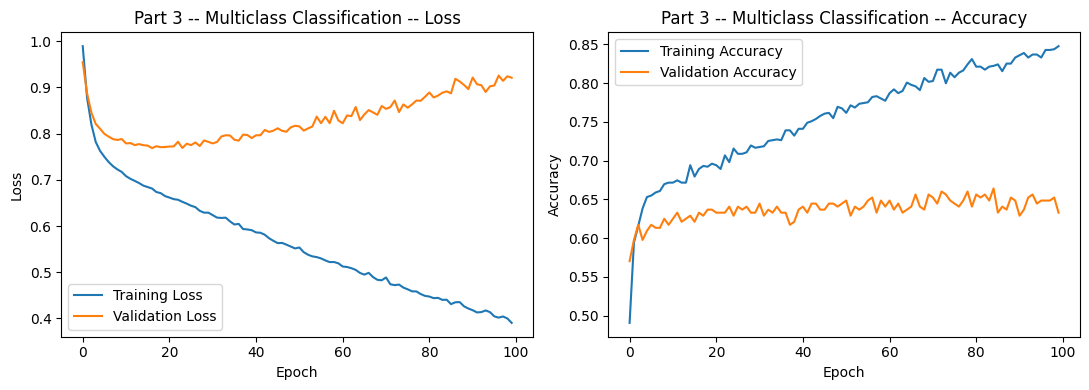

In [14]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

2. The graph shows overfitting. The training loss in the loss curve was continuously going down which mens the model was successfully learning the training data. However the validation loss was going down but at about 20 Epochs the validation loss started going up which shows overfitting as the gap between the training and validation loss grew.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part 3 -- Test Accuracy: 0.669


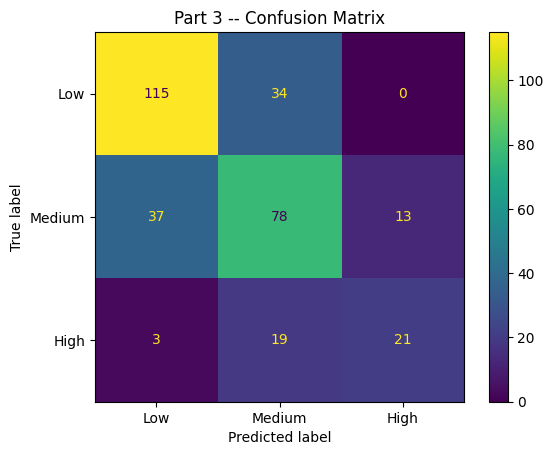

In [15]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

# Q: Which classes does your model confuse most often? Does that make sense
# given how the quality bands were constructed?
# Your answer: Low and medium are confused the most. This does make sense as medium was strictly bound to 6, while low had all numbers 0-5.


# Part B: Hyperparameter Tuning

In [16]:
!pip install keras-tuner --quiet
import keras_tuner as kt
def build_model(hp):
  model = tf.keras.Sequential([
    tf.keras.layers.Dense(
    hp.Int("hidden1", min_value=16, max_value=128, step=16),
    activation="relu", input_shape=(n_features,)
    ),
    tf.keras.layers.Dense(
      hp.Int("hidden2", min_value=8, max_value=64, step=8),
      activation="relu"
    ),
    tf.keras.layers.Dense(n_classes, activation="softmax")
  ])
  model.compile(
    optimizer=tf.keras.optimizers.Adam(
      hp.Choice("learning_rate", [0.001, 0.01, 0.1])
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
  )
  return model

IndentationError: expected an indented block after function definition on line 3 (2213176019.py, line 4)